# Simple linear regression - Exercise Solution

You are given a real estate dataset. 

Real estate is one of those examples that every regression course goes through as it is extremely easy to understand and there is a (almost always) certain causal relationship to be found.

The data is located in the file: 'real_estate_price_size.csv'. 

You are expected to create a simple linear regression (similar to the one in the lecture), using the new data. 

Apart from that, please:
-  Create a scatter plot (with or without a regression line)
-  Calculate the R-squared
-  Display the intercept and coefficient(s)
-  Using the model make a prediction about an apartment with size 750 sq.ft.

Note: In this exercise, the dependent variable is 'price', while the independent variable is 'size'.

Good luck!

## Import the relevant libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import LinearRegression

numpy is a package that contains several classes, functions, variables to deal with scientific calculation. It is useful to create or process N-dimensional arrays. It also conatins large library of Mathematical functions like Linear Algebra, Fourier Transformations. Check https://docs.scipy.org/doc/numpy/reference

panda helps to organize data into tabular format and provide data frames. It can work with numpy.

matplotlib is 2D plotting library specially designed for visualzing numpy computations.

All these are part of scipy group of libraries - SciPy is a python ecosystem contains lot of tools for scientific calculation.

Seaborn is a Python visualization Library based on matplotlib. It provides a high-level interface for drawing attractive statistical graphics.

Statmodels is package built on NumPy and SciPy which integrates with Pandas. SM provides very good summaries.
 
sk-learn or sci-kit learn is one of most widely used machine learning libraries  

## Load the data

Let us assume the linear euqation y = b + mx which is in form y = b0 + b1*x where slope is constant b1 and intercept is b0

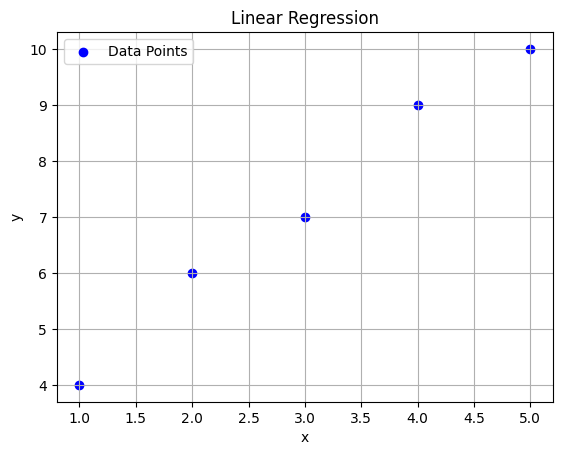

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define x values
x = np.array([1,2, 3,4, 5])
y = np.array([4, 6, 7, 9, 10])
# Compute y using the equation y = 4 + 2x
#y-hat = b + m * x


# Plot the points
plt.scatter(x, y, color='blue', label='Data Points')

# Plot the regression line
#plt.plot(x, y, color='red', label='Regression Line: y = 4 + 2x')

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


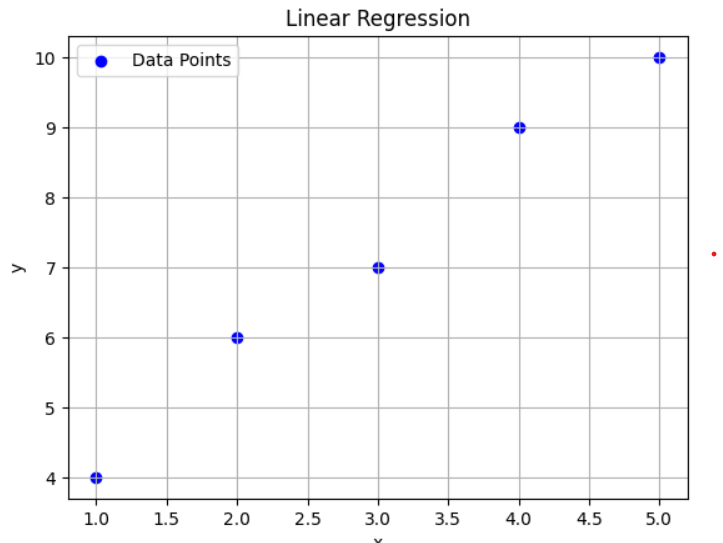

Explanation of Terms:
SSR: Sum of squares due to regression = variance explained by the model.
SSE: Sum of squared errors = residual variance (not explained).
SST: Total variance = SSR + SSE.
R²: Proportion of the variance explained by the model = SSR / SST.

Here is the R-squared table with your specified predicted values. It includes the squared errors (SSE), regression sum of squares (SSR), and the computed R-squared value at the bottom. Let me know if you'd like a visualization or to export the data. 
    

In [6]:
# We can Combine the lists into a list of tuples using zip()
#data = list(zip(x, y))

# Create the DataFrame, specifying column names
#df = pd.DataFrame(data, columns=['X', 'Y'])
ndf = pd.DataFrame()  #({'x': x, 'y': y})
ndf['ind_X']=x
ndf['dep_Y']=y
print(ndf)

   ind_X  dep_Y
0      1      4
1      2      6
2      3      7
3      4      9
4      5     10


In [9]:
import numpy as np
import pandas as pd

# Predicted y using model: y = 4 + 2x
#predicted_y = b + m * x

#based on data we can derive b and m
b=2.7 
m=1.5
yhat=1.5*x + 2.7

# Compute SSR (explained), SSE (residual), and SST (total)
y_mean = np.mean(y)
print(y_mean)

7.2


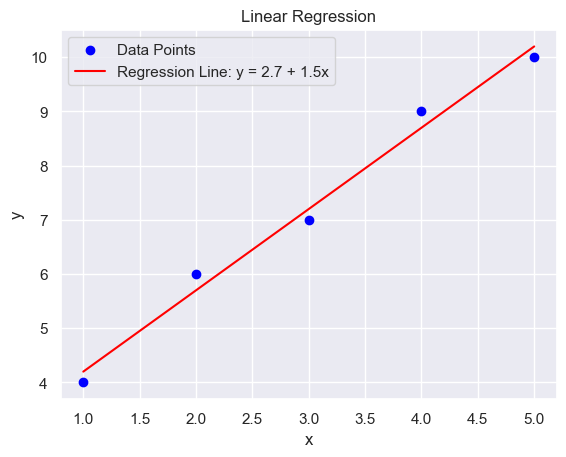

In [10]:
# Plot the points
plt.scatter(x, y, color='blue', label='Data Points')

# Plot the regression line
#plt.plot(x, y, color='red', label='Regression Line: y = 4 + 2x')
plt.plot(x, yhat, color='red', label='Regression Line: y = 2.7 + 1.5x')

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [22]:
ssr = np.sum((yhat - y_mean)**2)
sse = np.sum((y - yhat)**2)
sst = np.sum((y - y_mean)**2)
r_squared = ssr / sst

# Build table
ndf = pd.DataFrame({
    'x': x,
    'Observed_y': y,
    'Predicted_y': yhat,
    '(Obs - Pred)^2 (SSE)': (y - yhat)**2,
    '(Pred - Mean)^2 (SSR)': (yhat - y_mean)**2
})

# Add totals and R²
ndf.loc['Total'] = [
    '', '', '', 
    df['(Obs - Pred)^2 (SSE)'].sum(), 
    df['(Pred - Mean)^2 (SSR)'].sum()
]

# Display R-squared
print(ndf)
print(f"\nR-squared: {r_squared:.4f}")

       x Observed_y Predicted_y  (Obs - Pred)^2 (SSE)  (Pred - Mean)^2 (SSR)
0      1          4         4.2                  0.04                   9.00
1      2          6         5.7                  0.09                   2.25
2      3          7         7.2                  0.04                   0.00
3      4          9         8.7                  0.09                   2.25
4      5         10        10.2                  0.04                   9.00
Total                                            0.60                  45.00

R-squared: 0.9868


In [17]:
# We import LinearRegression Class from sklearn linear_model package  
from sklearn.linear_model import LinearRegression
reg=LinearRegression()    # We need to create object for LinearRegression class 

In [42]:
ndf.Predicted_y = ndf.Predicted_y.apply(pd.to_numeric, errors='coerce') 
ndf.x = ndf.x.apply(pd.to_numeric, errors='coerce') 
type(ndf.Predicted_y)
ndf.Predicted_y

0         4.2
1         5.7
2         7.2
3         8.7
4        10.2
Total     NaN
Name: Predicted_y, dtype: float64

In [1]:
#independent variabled x to be supplied as 2D array to the fit method
#Fitting means model has been trained with data - so model could have tried the data in the form of a straight line
shp_X=ndf.x.values.reshape(-1,1)
#reg.fit(shp_X, y)


NameError: name 'ndf' is not defined

C:\Users\Subham\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


1.0


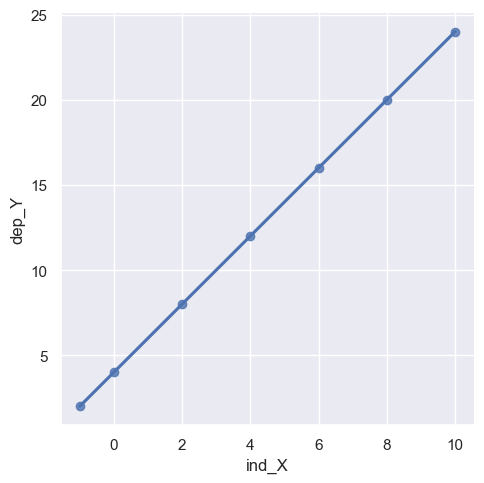

In [60]:
#Once model understand linear relation then the same can be used for predicting y
from sklearn.metrics import r2_score
y_original=df.dep_Y
y_predicted = reg.predict(df[['ind_X']])
r_square = r2_score(y_original, y_predicted)
print(r_square)
sns.lmplot(data=df, x='ind_X',y='dep_Y')

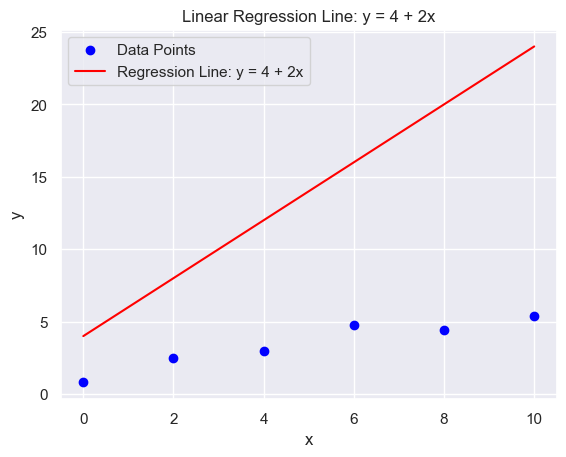

In [77]:
y=observed_y
plt.scatter(x, y, color='blue', label='Data Points')

# Plot the regression line

plt.plot(x, predicted_y, color='red', label='Regression Line: y = 4 + 2x')

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Line: y = 4 + 2x')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


In [48]:
data = pd.read_csv('real_estate_price_size.csv')
data.head()
data.tail()

,price,size
95,252460.400,549.80
96,310522.592,1037.44
97,383635.568,1504.75
98,225145.248,648.29
99,274922.856,705.29


In [49]:
data.describe()

,price,size
count,100.000000,100.000000
mean,292289.470160,853.024200
std,77051.727525,297.941951
min,154282.128000,479.750000
25%,234280.148000,643.330000
50%,280590.716000,696.405000
75%,335723.696000,1029.322500
max,500681.128000,1842.510000


## Create the regression

### Declare the dependent and the independent variables

In [50]:
x = data['size']
y = data['price']

### Explore the data

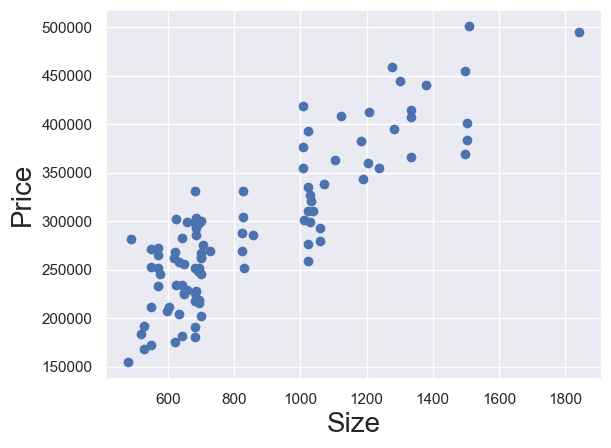

In [51]:
plt.scatter(x,y)
plt.xlabel('Size',fontsize=20)
plt.ylabel('Price',fontsize=20)
#plt.plot(x, y, color='red', linestyle='--', label='Regression Line (y = 4 + 2x)')
plt.show()

### Transform the inputs into a matrix (2D object)

In [52]:
print(x)
x_matrix = x.values.reshape(-1,1)
print(x_matrix)

0      643.09
1      656.22
2      487.29
3     1504.75
4     1275.46
       ...   
95     549.80
96    1037.44
97    1504.75
98     648.29
99     705.29
Name: size, Length: 100, dtype: float64
[[ 643.09]
 [ 656.22]
 [ 487.29]
 [1504.75]
 [1275.46]
 [ 575.19]
 [ 570.89]
 [ 620.82]
 [ 682.26]
 [ 694.52]
 [1060.36]
 [1842.51]
 [ 694.52]
 [1009.25]
 [1300.96]
 [1379.72]
 [ 690.54]
 [ 623.94]
 [ 681.07]
 [1027.76]
 [ 620.71]
 [ 549.69]
 [1207.45]
 [ 518.38]
 [ 525.81]
 [1103.3 ]
 [ 570.89]
 [1334.1 ]
 [ 681.07]
 [1496.36]
 [1010.33]
 [ 681.07]
 [ 597.9 ]
 [ 525.81]
 [ 857.54]
 [ 622.97]
 [ 823.21]
 [ 570.25]
 [ 685.48]
 [ 698.29]
 [1021.95]
 [ 682.26]
 [ 823.21]
 [1334.1 ]
 [1060.36]
 [ 698.29]
 [ 633.19]
 [ 698.29]
 [ 633.19]
 [ 617.05]
 [ 647.5 ]
 [1021.95]
 [1021.95]
 [ 727.88]
 [ 647.5 ]
 [1508.84]
 [1032.06]
 [1283.85]
 [ 827.84]
 [ 569.17]
 [ 828.16]
 [ 698.5 ]
 [1205.62]
 [1021.95]
 [ 685.48]
 [ 827.09]
 [1009.25]
 [ 549.8 ]
 [ 685.48]
 [1496.36]
 [1021.95]
 [ 643.41]
 [ 656.22]
 [ 

### Regression itself

In [53]:
reg = LinearRegression()
reg.fit(x_matrix,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Calculate the R-squared

In [54]:
reg.score(x_matrix,y)

0.7447391865847587

### Find the intercept

In [55]:
reg.intercept_

np.float64(101912.60180122912)

### Find the coefficients

In [58]:
reg.coef_

array([223.17874259])

In [61]:
import statsmodels.api as sm
x1 = sm.add_constant(x)
results = sm.OLS(y,x1).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     285.9
Date:                Sun, 13 Jul 2025   Prob (F-statistic):           8.13e-31
Time:                        15:57:34   Log-Likelihood:                -1198.3
No. Observations:                 100   AIC:                             2401.
Df Residuals:                      98   BIC:                             2406.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.019e+05   1.19e+04      8.550      0.000    7.83e+04    1.26e+05
size         223.1787     13.199     16.909      0.000     196.986     249.371
==============================================================================
Omnibus:                        6.262   Durbin-Watson:                   2.267
Prob(Omnibus):                  0.044   Jarque-Bera (JB):                2.938
Skew:                           0.117   Prob(JB):                        0.230
Kurtosis:                       2.194   Cond. No.                     2.75e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.75e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

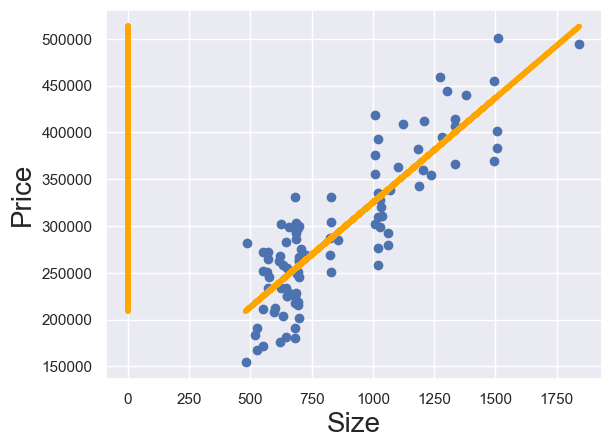

In [62]:
plt.scatter(x,y)
yhat = x*223.1787+101900
fig = plt.plot(x1,yhat, lw=4, c='orange', label ='regression line')
plt.xlabel('Size', fontsize = 20)
plt.ylabel('Price', fontsize = 20)
plt.show()

### Making predictions

You find an apartment online with a size of 750 sq.ft.

All else equal what should be its price according to the model?

In [63]:
reg.predict([[750]])

array([269296.65874718])

C:\Users\mitra\AppData\Local\Temp\ipykernel_17972\560859782.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = results.params[0] + results.params[1] * x_range


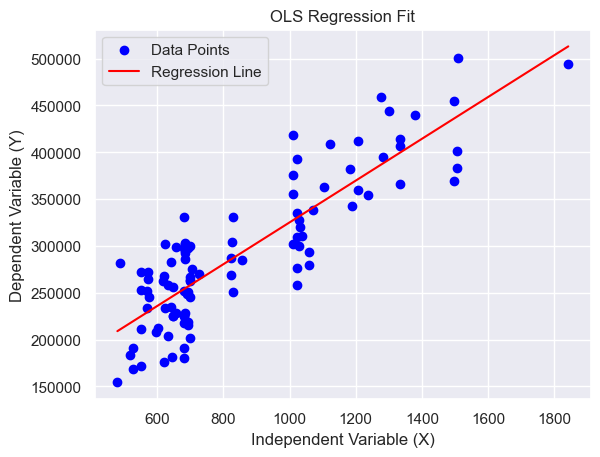

In [75]:
plt.scatter(x,y, color='blue', label='Data Points')

x_range = np.linspace(data['size'].min(), data['size'].max(), 100)
#ser.iloc[0]
y_pred = results.params[0] + results.params[1] * x_range 

plt.plot(x_range, y_pred, color='red', label='Regression Line')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (Y)')
plt.title('OLS Regression Fit')
plt.legend()
plt.show()

### Train and Test Split 

In [104]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state =0)
# random_state specify the seed - if seed is 0 then 

In [109]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
x_train1 = x_train.values.reshape(-1,1)
reg.fit(x_train1, y_train)

LinearRegression()

#### Training is done with Training sets of data (x_train). Now we will test the model with test set of data - x_test

In [111]:
x_test1 = x_test.values.reshape(-1,1)
y_pred = reg.predict(x_test1)
y_pred

array([228059.16381052, 208298.80641537, 209933.57813755, 431419.12890582,
       252903.79134959, 255681.16877149, 254000.86627191, 223486.57287939,
       244669.22503548, 223486.57287939, 262096.67212153, 254863.7829104 ,
       252205.65276267, 323101.40945174, 238884.64817239, 323335.56773555,
       366073.79079604, 218285.22359357, 218285.22359357, 252205.65276267,
       393533.18583769, 365677.02259291, 430532.36281249, 243782.45894215,
       255681.16877149, 241566.62777495, 228059.16381052, 257198.86135177,
       251947.64502402, 360872.44151022])

In [113]:
r2_score(y_test, y_pred)

0.7277153827291032

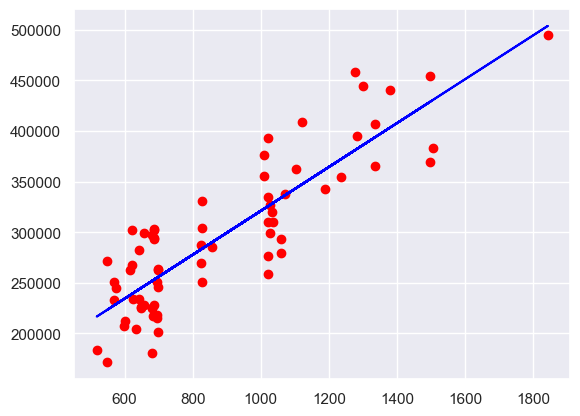

In [118]:
plt.scatter(x_train,y_train,color='red')
plt.plot(x_train,reg.predict(x_train1),color='blue')

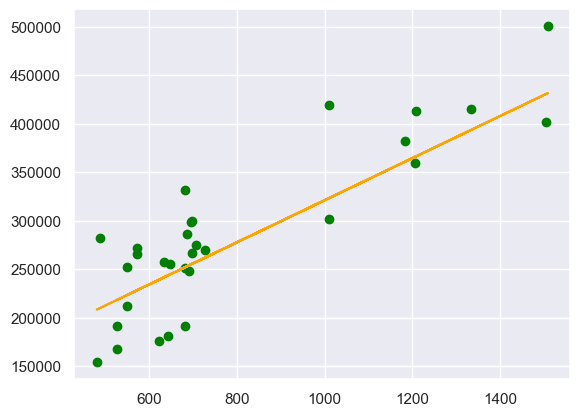

In [119]:
plt.scatter(x_test,y_test,color='green')
plt.plot(x_test,reg.predict(x_test1),color='orange')